In [1]:
!pip install -q lightgbm imbalanced-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
csv_path = "/content/model_training_data_le.csv"
assert os.path.exists(csv_path), f"CSV not found at {csv_path}"
df = pd.read_csv(csv_path)
print("Loaded shape:", df.shape)

FEATURES = [
    "month",
    "-0_days_game_scheduled",
    "sum_field_goals_attempted",
    "sum_minutes",
    "sum_injury_history",
    "1st_recent_region",
    "2nd_recent_region",
    "3rd_recent_region",
    "4th_recent_region"
]
TARGET = "injured?"

missing = [c for c in FEATURES + [TARGET] if c not in df.columns]
if missing:
    raise ValueError("Missing required columns: " + str(missing))

X = df[FEATURES].copy()
y = df[TARGET].copy().astype(int)
print("Feature sample:")
display(X.head())
print("Target distribution:")
print(y.value_counts(normalize=True))

Loaded shape: (404369, 18)
Feature sample:


,month,-0_days_game_scheduled,sum_field_goals_attempted,sum_minutes,sum_injury_history,1st_recent_region,2nd_recent_region,3rd_recent_region,4th_recent_region
0,Oct,1,11.0,37.0,106,SW,RM,S,NW
1,Oct,0,13.0,44.0,105,SW,RM,S,NW
2,Oct,0,13.0,44.0,104,SW,RM,S,NW
3,Oct,1,13.0,44.0,103,NW,SW,RM,S
4,Oct,0,16.0,51.0,102,NW,SW,RM,S


Target distribution:
injured?
0    0.999075
1    0.000925
Name: proportion, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train label distribution:\n", y_train.value_counts(normalize=True))

Train: (323495, 9) Test: (80874, 9)
Train label distribution:
 injured?
0    0.999076
1    0.000924
Name: proportion, dtype: float64


In [4]:
numeric_features = ["sum_field_goals_attempted", "sum_minutes", "sum_injury_history"]
categorical_features = ["month", "-0_days_game_scheduled", "1st_recent_region", "2nd_recent_region", "3rd_recent_region", "4th_recent_region"]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print("Transformed shapes:", X_train_proc.shape, X_test_proc.shape)

Transformed shapes: (323495, 36) (80874, 36)


In [5]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
roc_scores = cross_val_score(lgbm, X_train_proc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
f1_scores  = cross_val_score(lgbm, X_train_proc, y_train, cv=cv, scoring='f1', n_jobs=-1)

print(f"CV ROC-AUC (5-fold): mean={roc_scores.mean():.4f}, std={roc_scores.std():.4f}")
print(f"CV F1     (5-fold): mean={f1_scores.mean():.4f}, std={f1_scores.std():.4f}")

CV ROC-AUC (5-fold): mean=0.8542, std=0.0219
CV F1     (5-fold): mean=0.0180, std=0.0060


In [6]:
do_tune = True

if do_tune:
    param_dist = {
        'n_estimators': [100, 200, 400],
        'max_depth': [ -1, 6, 10, 16],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 63, 127],
        'min_child_samples': [5, 10, 20],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    }

    lgbm_base = LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

    rs = RandomizedSearchCV(
        estimator=lgbm_base,
        param_distributions=param_dist,
        n_iter=16,           # reduce to 8 for faster runs
        scoring='roc_auc',
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    rs.fit(X_train_proc, y_train)
    print("Best params:", rs.best_params_)
    print("Best CV ROC-AUC:", rs.best_score_)
    best_est = rs.best_estimator_
else:
    best_est = LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Number of positive: 299, number of negative: 323196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011481 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 689
[LightGBM] [Info] Number of data points in the train set: 323495, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best params: {'subsample': 0.6, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.8867039725776684


In [7]:
from sklearn.model_selection import train_test_split
from lightgbm.callback import early_stopping, log_evaluation

X_tr, X_val, y_tr, y_val = train_test_split(X_train_proc, y_train, test_size=0.1, stratify=y_train, random_state=42)

if 'best_est' not in globals():
    best_est = LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')

best_est.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[early_stopping(stopping_rounds=30, verbose=True)]
)

y_proba = best_est.predict_proba(X_test_proc)[:,1]
y_pred = (y_proba >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_proba)
test_f1 = f1_score(y_test, y_pred)

print("Test ROC-AUC:", round(test_auc,4))
print("Test F1:", round(test_f1,4))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

[LightGBM] [Info] Number of positive: 269, number of negative: 290876
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059999 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 689
[LightGBM] [Info] Number of data points in the train set: 291145, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[33]	valid_0's auc: 0.898923	valid_0's binary_logloss: 0.529938
Test ROC-AUC: 0.8674
Test F1: 0.0095

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.92     80799
           1       0.00      0.75      0.01        75

    accuracy                           0.86     80874
   macro avg       0.50      0.80      0.47     80874
weighted avg 

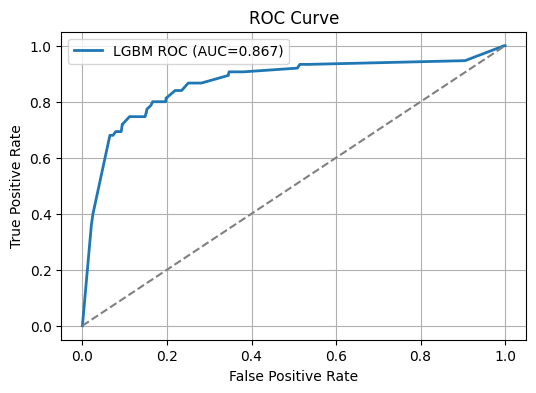

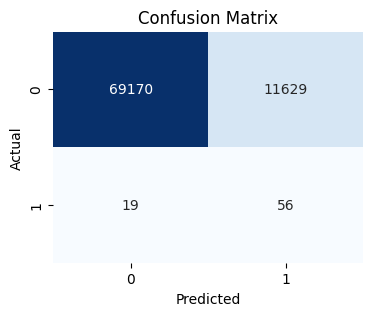

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'LGBM ROC (AUC={test_auc:.3f})', linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend(); plt.grid(True); plt.show()

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3)); sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix'); plt.show()

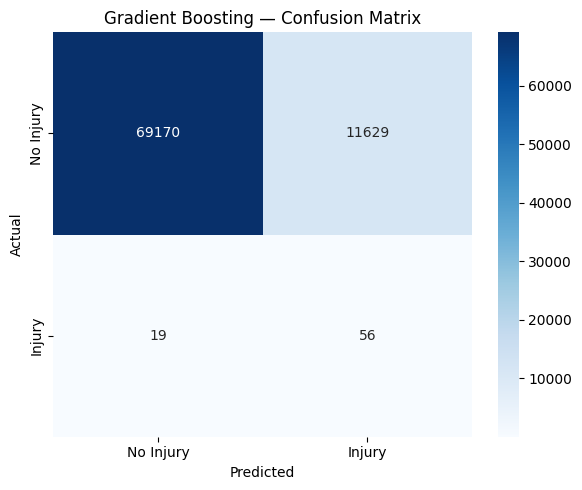

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

cm = np.array(cm, dtype=int)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Injury', 'Injury'],
            yticklabels=['No Injury', 'Injury'],
            cbar=True)
plt.title("Gradient Boosting — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("GB_Confusion_Matrix.png", dpi=300)
plt.show()

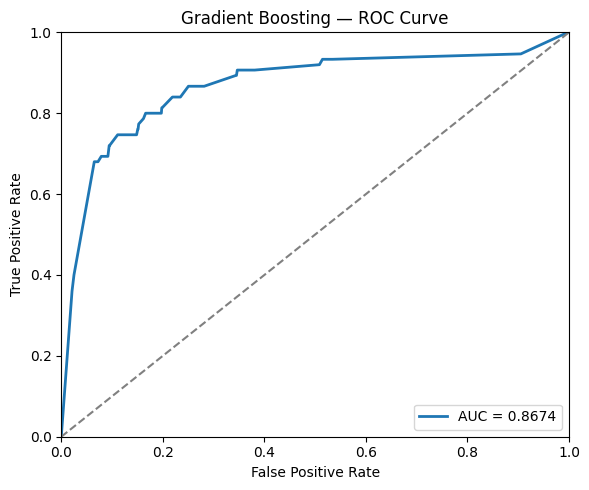

In [12]:
import matplotlib.pyplot as plt
fpr = np.array(fpr, dtype=float)
tpr = np.array(tpr, dtype=float)
auc_score = float(test_auc) if (not isinstance(test_auc, str)) else test_auc

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc_score:.4f}')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting — ROC Curve")
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("GB_ROC_Curve.png", dpi=300)
plt.show()

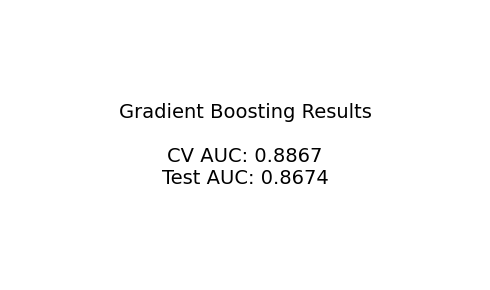

In [14]:
import matplotlib.pyplot as plt

# Use rs.best_score_ for CV AUC and test_auc for Test AUC
cv_auc_display = f"{rs.best_score_:.4f}"
test_auc_display = f"{test_auc:.4f}"

plt.figure(figsize=(5,3))
plt.axis('off')
text = f"Gradient Boosting Results\n\nCV AUC: {cv_auc_display}\nTest AUC: {test_auc_display}"
plt.text(0.5, 0.5, text, ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.savefig("GB_AUC_Summary.png", dpi=300)
plt.show()

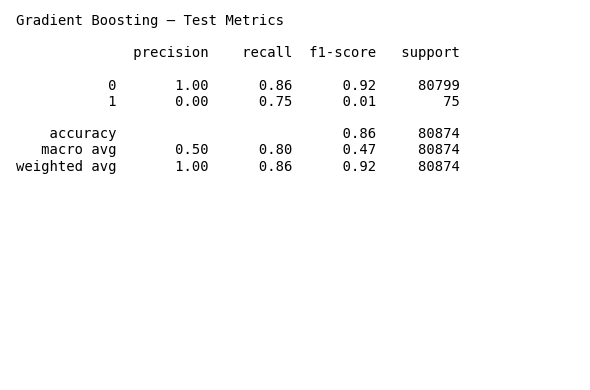

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

plt.figure(figsize=(6,4))
plt.axis('off')

# Calculate the classification report again as it was not assigned to a variable previously
class_report_text = classification_report(y_test, y_pred)

metrics_text = f"Gradient Boosting — Test Metrics\n\n{class_report_text}"
plt.text(0.01, 0.99, metrics_text, ha='left', va='top', fontsize=10, family='monospace')
plt.tight_layout()
plt.savefig("GB_Metrics_Summary.png", dpi=300)
plt.show()

In [17]:
from google.colab import files
files.download("GB_Confusion_Matrix.png")
files.download("GB_ROC_Curve.png")
files.download("GB_AUC_Summary.png")
files.download("GB_Metrics_Summary.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>